# 01 — Generate the scientific problem-solving SFT dataset

The student model receives a **task only**—never a paper passage. Openly licensed
scientific text is authoring material for `gpt-5.6-terra`, which creates a new,
self-contained task and one strong structured work product:

```text
<brainstorm>distinct candidate ideas</brainstorm>
<principles>scientific constraints and design principles</principles>
<synthesis>comparison or integration of the candidates</synthesis>
<answer>concise final proposal or conclusion</answer>
```

A second critic call checks every generated record against the source. The
generator continues until the requested number of **accepted** examples is
available in every task family and SFT split.

## Before you run

```bash
python3.12 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install -e ".[dev]"
export OPENAI_API_KEY="..."
hf auth login
jupyter lab
```

Generation is real API use. Drafts and rejections are appended incrementally, so
interruption and rerun are safe. Increasing the targets may require increasing
the source pool and generation-attempt budget.

## Configuration

Every editable non-secret parameter is below. Only `OPENAI_API_KEY` is required
from the environment. Hugging Face uses cached `hf auth login` credentials unless
the optional token line is deliberately uncommented.

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import JSON, Markdown, display

from science_course.data import (
    TASK_FAMILIES,
    allocate_task_quotas,
    build_sft_dataset,
    read_jsonl,
    stream_open_science_sources,
    task_quota_status,
    write_jsonl,
)
from science_course.hub import require_hf_namespace
from science_course.teacher import (
    DEFAULT_CRITIC_MODEL,
    DEFAULT_TEACHER_MODEL,
    generate_canonical_tasks,
    require_openai_key,
)

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data"

# Local artifacts: v2 paths prevent accidental reuse of the earlier QA dataset
RAW_SOURCES = DATA / "raw" / "scientific_design_sft_sources.jsonl"
ACCEPTED = DATA / "canonical" / "scientific_design_sft_tasks.jsonl"
REJECTED = DATA / "canonical" / "scientific_design_sft_rejected.jsonl"
SFT_DISK = DATA / "processed" / "scientific_design_sft"

# Teacher and independent critic
TEACHER_MODEL = DEFAULT_TEACHER_MODEL
CRITIC_MODEL = DEFAULT_CRITIC_MODEL

# Exact accepted-example targets
SFT_SPLIT_TARGETS = {
    "sft_train": 500,
    "sft_validation": 75,
}
TASK_FAMILY_WEIGHTS = {
    "mechanism_guided_design": 0.25,
    "experimental_design": 0.25,
    "troubleshooting": 0.20,
    "hypothesis_development": 0.15,
    "cross_domain_synthesis": 0.15,
}

# Open scientific source pool
SOURCE_DATASET_ID = "common-pile/peS2o"
SOURCE_SPLIT = "train"
SOURCE_CANDIDATE_LIMIT = 2_500
MAX_SOURCE_RECORDS_SCANNED = 200_000
MIN_SOURCE_CHARS = 1_200
MAX_SOURCE_CHARS = 6_000
RANDOM_SEED = 17

# Resumable API generation
GENERATION_CONCURRENCY = 8
MAX_GENERATION_ATTEMPTS = 2_500
OPENAI_MAX_RETRIES = 3
OPENAI_TIMEOUT_SECONDS = 120.0

# Hugging Face publication
DATASET_HF_REPO = "lamm-mit/scientific-sft-grpo-data"
DATASET_CONFIG_NAME = "scientific_design_sft"
PUSH_DATASETS_TO_HUB = True
DATASET_PRIVATE = False
HF_TOKEN = None
# HF_TOKEN = os.environ["HF_TOKEN"]  # Optional; prefer `hf auth login`.

require_openai_key()
if set(TASK_FAMILY_WEIGHTS) != set(TASK_FAMILIES):
    raise ValueError(f"Define weights for exactly these families: {TASK_FAMILIES}")
if PUSH_DATASETS_TO_HUB:
    require_hf_namespace(DATASET_HF_REPO, token=HF_TOKEN)

sns.set_theme(style="whitegrid", context="talk")
display(
    JSON(
        {
            "teacher_model": TEACHER_MODEL,
            "critic_model": CRITIC_MODEL,
            "accepted_targets": SFT_SPLIT_TARGETS,
            "accepted_total": sum(SFT_SPLIT_TARGETS.values()),
            "source_candidates": SOURCE_CANDIDATE_LIMIT,
            "generation_concurrency": GENERATION_CONCURRENCY,
            "dataset_hub_repo": DATASET_HF_REPO,
            "dataset_config": DATASET_CONFIG_NAME,
        }
    )
)

<IPython.core.display.JSON object>

## 1. Acquire open scientific authoring material

Only license-filtered source excerpts are sent to the teacher. Paper ID, URL,
license, and content hash are retained locally for provenance. The source text is
never placed in the student prompt or published training projection.

In [2]:
cached_sources = read_jsonl(RAW_SOURCES)
cache_is_usable = (
    len(cached_sources) == SOURCE_CANDIDATE_LIMIT
    and all(
        row.get("source_dataset") == SOURCE_DATASET_ID
        and row.get("source_split") == SOURCE_SPLIT
        for row in cached_sources
    )
)
if cache_is_usable:
    sources = cached_sources
    print(f"Reusing {len(sources)} cached sources from {RAW_SOURCES}")
else:
    sources = stream_open_science_sources(
        dataset_id=SOURCE_DATASET_ID,
        split=SOURCE_SPLIT,
        max_papers=SOURCE_CANDIDATE_LIMIT,
        max_scanned=MAX_SOURCE_RECORDS_SCANNED,
        min_chars=MIN_SOURCE_CHARS,
        max_chars=MAX_SOURCE_CHARS,
        seed=RANDOM_SEED,
    )
    write_jsonl(RAW_SOURCES, sources)
    print(f"Cached {len(sources)} source candidates at {RAW_SOURCES}")

if len(sources) < sum(SFT_SPLIT_TARGETS.values()):
    raise RuntimeError(
        "The source pool is smaller than the accepted-example target. "
        "Increase SOURCE_CANDIDATE_LIMIT."
    )
source_frame = pd.DataFrame(sources)
display(
    source_frame[
        ["paper_id", "title", "source_license", "source_url"]
    ].head()
)

Reusing 2500 cached sources from /Users/mbuehler/Applied AI Course/scientific-sft-grpo-course/data/raw/scientific_design_sft_sources.jsonl


,paper_id,title,source_license,source_url
0,219175152,219175152,CCBY,https://www.nature.com/articles/s41467-020-163...
1,245515439,245515439,CCBY,https://www.mdpi.com/2073-445X/11/1/35/pdf
2,258874234,258874234,CCBY,https://doi.org/10.1177/20417314231174609
3,258441903,258441903,CCBY,http://www.brainstimjrnl.com/article/S1935861X...
4,259759805,259759805,CCBYSA,https://journal.ypidathu.or.id/index.php/abdim...


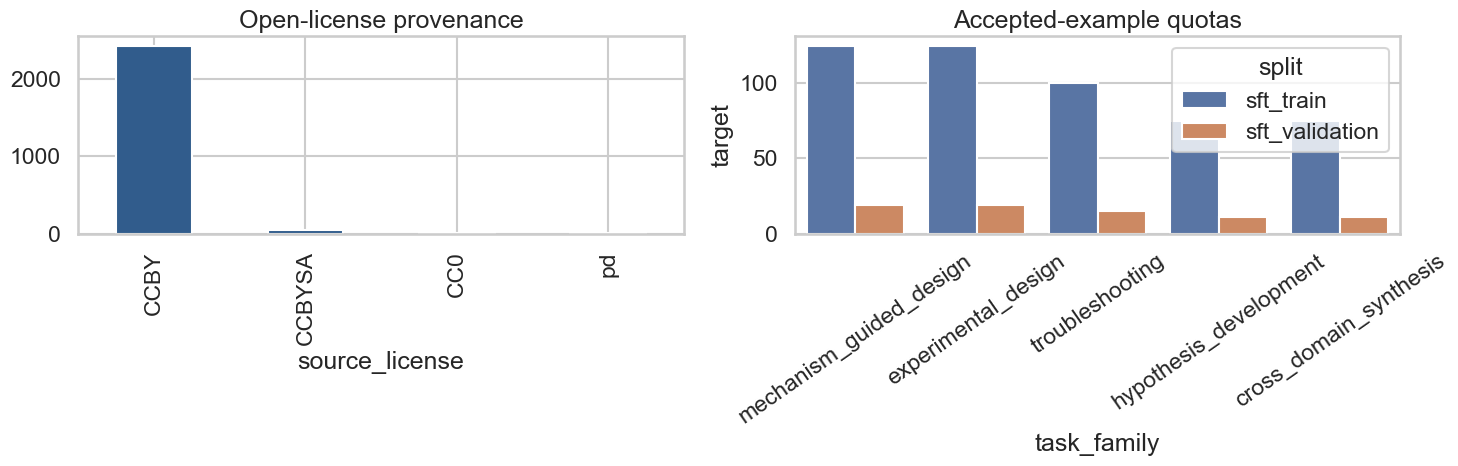

In [3]:
quota = allocate_task_quotas(SFT_SPLIT_TARGETS, TASK_FAMILY_WEIGHTS)
quota_frame = pd.DataFrame(
    [
        {"split": split, "task_family": family, "target": target}
        for (split, family), target in quota.items()
    ]
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
source_frame["source_license"].value_counts().head(12).plot.bar(
    ax=axes[0], color="#315c8c", title="Open-license provenance"
)
sns.barplot(
    quota_frame,
    x="task_family",
    y="target",
    hue="split",
    ax=axes[1],
)
axes[1].set_title("Accepted-example quotas")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 2. Generate until the accepted quotas are full

Each source is assigned to the currently most underfilled `(split, task_family)`
cell. Rejected drafts do not consume a quota. Concurrent calls improve throughput,
while all completed records are written immediately for safe resumption.

In [4]:
canonical = generate_canonical_tasks(
    sources,
    accepted_path=ACCEPTED,
    rejected_path=REJECTED,
    split_targets=SFT_SPLIT_TARGETS,
    task_family_weights=TASK_FAMILY_WEIGHTS,
    teacher_model=TEACHER_MODEL,
    critic_model=CRITIC_MODEL,
    concurrency=GENERATION_CONCURRENCY,
    max_attempts=MAX_GENERATION_ATTEMPTS,
    api_max_retries=OPENAI_MAX_RETRIES,
    api_timeout_seconds=OPENAI_TIMEOUT_SECONDS,
)
rejected = read_jsonl(REJECTED)
status = task_quota_status(
    canonical,
    SFT_SPLIT_TARGETS,
    TASK_FAMILY_WEIGHTS,
)
if not status["complete"]:
    raise RuntimeError(f"Unfilled quotas: {status['deficits']}")
print(
    {
        "accepted": len(canonical),
        "rejected": len(rejected),
        "acceptance_rate": len(canonical)
        / max(len(canonical) + len(rejected), 1),
        "split_counts": pd.Series(
            [row["split"] for row in canonical]
        ).value_counts().to_dict(),
    }
)

Accepted scientific tasks (gpt-5.6-terra):  28%|##8       | 162/575 [00:00<?, ?it/s]

{'accepted': 575, 'rejected': 461, 'acceptance_rate': 0.555019305019305, 'split_counts': {'sft_train': 500, 'sft_validation': 75}}


In [5]:
example = canonical[0]
display(Markdown("### Student-visible task"))
display(Markdown(example["task"]))
display(Markdown("### Reference structured work product"))
display(
    JSON(
        {
            "brainstorm": example["brainstorm"],
            "principles": example["principles"],
            "synthesis": example["synthesis"],
            "answer": example["answer"],
        }
    )
)
display(Markdown("### Hidden task-specific rubric"))
display(
    JSON(
        {
            "required_constraints": example["required_constraints"],
            "evaluation_criteria": example["evaluation_criteria"],
            "acceptable_alternatives": example["acceptable_alternatives"],
            "failure_modes": example["failure_modes"],
        }
    )
)

### Student-visible task

A city medical school, primary-care network, and social-service organizations are redesigning care after COVID-19 exposed gaps for LGBTQ+ people, persons experiencing homelessness, and migrant farm workers. These groups are socially marginalized, may be uninsured, face adverse social determinants of health, and are less likely to use primary care outside emergency care. The partners must propose one integrated research-and-service direction that transfers useful principles across all three groups without treating them as identical. Explain: (1) a shared access and care-coordination model spanning clinical practice, medical education, and social organizations; (2) how the model can be adapted to each group’s distinct circumstances while avoiding stigma; and (3) a qualitative evaluation plan linking access, quality, utilization, coordination, and treatment. State one plausible risk or unintended consequence and a safeguard. Do not assume that any group has the same needs, insurance status, or preferred setting.

### Reference structured work product

<IPython.core.display.JSON object>

### Hidden task-specific rubric

<IPython.core.display.JSON object>

## 3. Audit the curriculum

The audit checks family balance and whether the reference work products contain
multiple candidates and explicit principles. It does not assume that longer
answers are better.

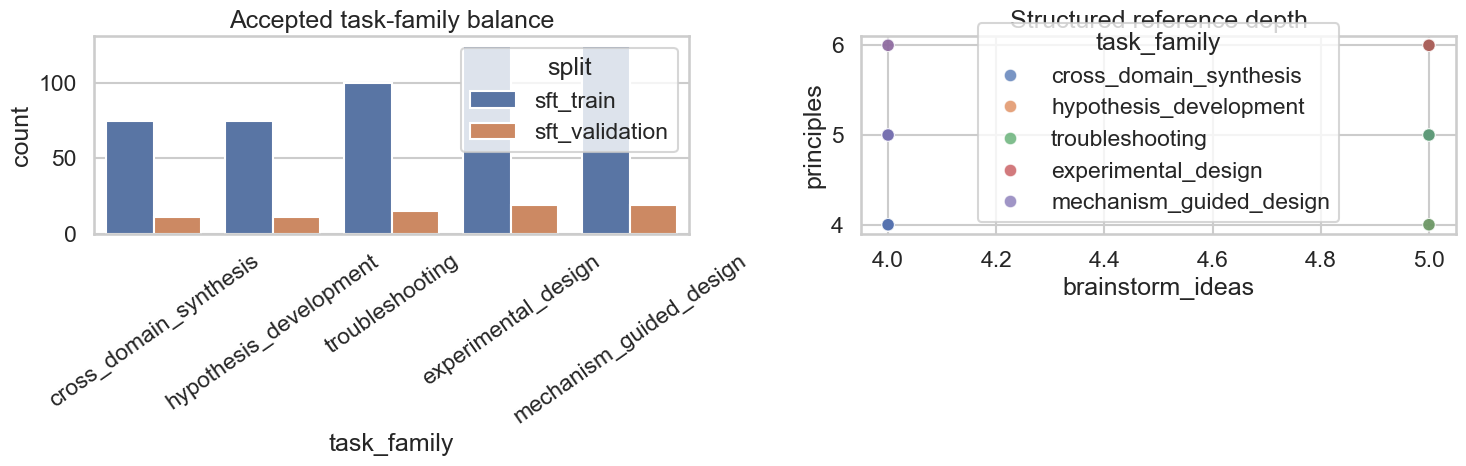

In [6]:
audit = pd.DataFrame(
    [
        {
            "split": row["split"],
            "task_family": row["task_family"],
            "task_chars": len(row["task"]),
            "brainstorm_ideas": len(row["brainstorm"]),
            "principles": len(row["principles"]),
        }
        for row in canonical
    ]
)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(
    audit,
    x="task_family",
    hue="split",
    ax=axes[0],
)
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_title("Accepted task-family balance")
sns.scatterplot(
    audit,
    x="brainstorm_ideas",
    y="principles",
    hue="task_family",
    alpha=0.75,
    ax=axes[1],
)
axes[1].set_title("Structured reference depth")
plt.tight_layout()
plt.show()

## 4. Build and publish the SFT projection

SFT receives `prompt + completion`. Raw source text, critic metadata, and the
hidden grading rubric are excluded from this projection.

In [7]:
sft = build_sft_dataset(canonical)
expected_splits = {
    "train": SFT_SPLIT_TARGETS["sft_train"],
    "validation": SFT_SPLIT_TARGETS["sft_validation"],
}
actual_splits = {name: len(split) for name, split in sft.items()}
if actual_splits != expected_splits:
    raise RuntimeError(
        f"Unexpected SFT split sizes: {actual_splits}; expected {expected_splits}"
    )
if SFT_DISK.exists():
    shutil.rmtree(SFT_DISK)
sft.save_to_disk(SFT_DISK)
for split_name, split_data in sft.items():
    split_data.to_parquet(
        DATA / "processed" / f"scientific_design_sft_{split_name}.parquet"
    )
if PUSH_DATASETS_TO_HUB:
    sft.push_to_hub(
        DATASET_HF_REPO,
        config_name=DATASET_CONFIG_NAME,
        private=DATASET_PRIVATE,
        token=HF_TOKEN,
        commit_message="Publish scientific design SFT dataset",
    )

assert "source_text" not in sft["train"].column_names
assert "required_constraints" not in sft["train"].column_names
print(sft)
display(JSON(sft["train"][0]))

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/75 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Setting num_proc from 1 back to 1 for the train split to disable multiprocessing as it only contains one shard.


...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

DatasetDict({
    train: Dataset({
        features: ['task_id', 'paper_id', 'task_family', 'prompt', 'completion', 'source_license', 'source_url'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['task_id', 'paper_id', 'task_family', 'prompt', 'completion', 'source_license', 'source_url'],
        num_rows: 75
    })
})


<IPython.core.display.JSON object>

## Result

The SFT dataset contains 500 training and 75 validation tasks by default, balanced
across five scientific problem-solving families. Continue with notebook 02, which
generates a separate, paper-disjoint GRPO curriculum and its hidden rubrics.